# 03. Budget Optimization

Optimize a fixed 13-week media budget and compare it with the current media mix.

In [89]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from pymc_marketing.mmm.multidimensional import (
    MMM,
    MultiDimensionalBudgetOptimizerWrapper,
)

ROOT = next(
    p for p in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    if (p / "demo").exists()
)

DATE = "Weeks"
CHANNELS = [
    "Google Search", "DV360", "Facebook", "AMS",
    "TV", "VOD", "OOH", "Radio"
]

SPEND_UNIT = 10_000
REVENUE_UNIT = 375_000

df = pd.read_csv(ROOT / "demo/data/mock_cgp_data.csv", parse_dates=[DATE])
train = df.iloc[:-52].copy()

mmm = MMM.load(ROOT / "demo/artifacts/mmm_demo_8ch.nc")

In [90]:
HORIZON = 13

current = train.tail(HORIZON)[CHANNELS].sum()
budget = current.sum()

current_allocation = xr.DataArray(
    current.values,
    dims="channel",
    coords={"channel": CHANNELS},
)

current_table = pd.DataFrame({
    "Current Spend ($)": current * SPEND_UNIT,
    "Current Mix": current / budget,
})

display(
    current_table.style.format({
        "Current Spend ($)": "${:,.0f}",
        "Current Mix": "{:.1%}",
    })
)

print(f"13-week budget: ${budget * SPEND_UNIT:,.0f}")

,Current Spend ($),Current Mix
Google Search,"$349,070",6.7%
DV360,"$407,247",7.9%
Facebook,"$250,362",4.8%
AMS,"$198,673",3.8%
TV,"$2,606,501",50.3%
VOD,"$347,644",6.7%
OOH,"$810,809",15.7%
Radio,"$207,299",4.0%


13-week budget: $5,177,605


In [91]:
# ============================================================
# 13-week budget optimization with business guardrails
# ============================================================

start_date = train[DATE].max() + pd.Timedelta(weeks=1)
end_date = start_date + pd.Timedelta(weeks=12)

optimizer = MultiDimensionalBudgetOptimizerWrapper(
    model=mmm,
    start_date=start_date,
    end_date=end_date,
)

# ------------------------------------------------------------
# Channel-specific bounds
#
# Most channels: 75%–150% of current spend
# TV:            75%–100% of current spend
# OOH:           75%–90%  of current spend
# ------------------------------------------------------------

lower = current.values * 0.75
upper = current.values * 1.50

# TV: allow reduction, but do not allow an increase
tv_idx = CHANNELS.index("TV")
upper[tv_idx] = current.values[tv_idx] * 1.00

# OOH: require at least a 10% reduction
ooh_idx = CHANNELS.index("OOH")
upper[ooh_idx] = current.values[ooh_idx] * 0.90

bounds = xr.DataArray(
    np.column_stack([lower, upper]),
    dims=["channel", "bound"],
    coords={
        "channel": CHANNELS,
        "bound": ["lower", "upper"],
    },
)

optimal_allocation, result = optimizer.optimize_budget(
    budget=budget,
    budget_bounds=bounds,
)

print("Optimization success:", result.success)

/opt/miniconda3/envs/walmart_mmm_312/lib/python3.12/site-packages/pymc_marketing/mmm/budget_optimizer.py:808: UserWarning: Using default equality constraint
  self.set_constraints(


Optimization success: True


,Current Spend ($),Optimal Spend ($),Current Mix,Optimal Mix
Google Search,"$349,070","$497,785",6.7%,9.6%
DV360,"$407,247","$610,870",7.9%,11.8%
Facebook,"$250,362","$375,543",4.8%,7.3%
AMS,"$198,673","$298,010",3.8%,5.8%
TV,"$2,606,501","$1,954,876",50.3%,37.8%
VOD,"$347,644","$521,466",6.7%,10.1%
OOH,"$810,809","$608,107",15.7%,11.7%
Radio,"$207,299","$310,948",4.0%,6.0%


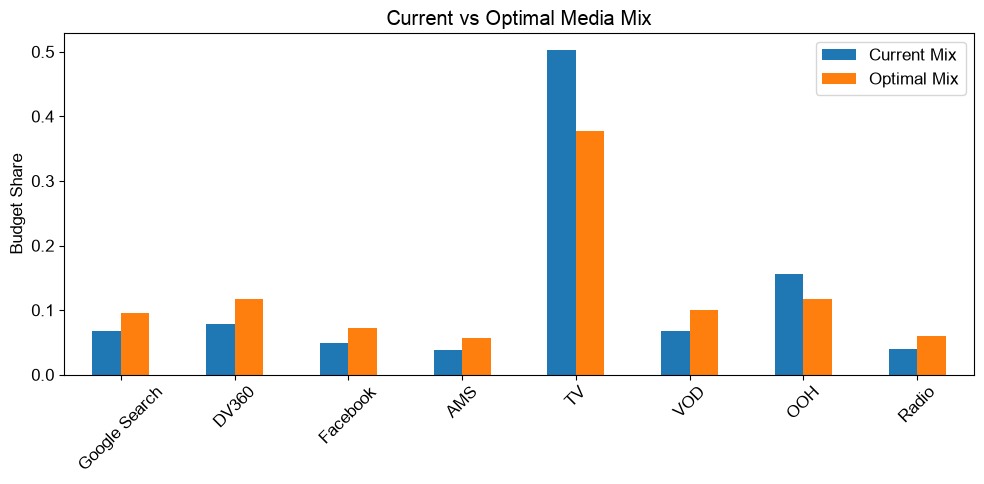

In [92]:
optimal = optimal_allocation.to_series()

comparison = pd.DataFrame({
    "Current Spend ($)": current * SPEND_UNIT,
    "Optimal Spend ($)": optimal * SPEND_UNIT,
    "Current Mix": current / budget,
    "Optimal Mix": optimal / optimal.sum(),
})

display(
    comparison.style.format({
        "Current Spend ($)": "${:,.0f}",
        "Optimal Spend ($)": "${:,.0f}",
        "Current Mix": "{:.1%}",
        "Optimal Mix": "{:.1%}",
    })
)

comparison[["Current Mix", "Optimal Mix"]].plot(
    kind="bar",
    figsize=(10, 5),
)

plt.ylabel("Budget Share")
plt.title("Current vs Optimal Media Mix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [93]:
current_samples = optimizer.sample_response_distribution(
    allocation_strategy=current_allocation
)

optimal_samples = optimizer.sample_response_distribution(
    allocation_strategy=optimal_allocation
)

def expected_revenue(samples):
    y = samples["y"]
    sample_dims = [d for d in ["chain", "draw", "sample"] if d in y.dims]

    return (
        y.sum("date")
        .median(dim=sample_dims)
        .item()
        * REVENUE_UNIT
    )

current_revenue = expected_revenue(current_samples)
optimal_revenue = expected_revenue(optimal_samples)

uplift = optimal_revenue / current_revenue - 1

print(f"Current mix expected revenue: ${current_revenue:,.0f}")
print(f"Optimal mix expected revenue: ${optimal_revenue:,.0f}")
print(f"Expected uplift: {uplift:.2%}")

Sampling: [y]
Sampling: [y]


Current mix expected revenue: $10,756,353
Optimal mix expected revenue: $11,922,234
Expected uplift: 10.84%


Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

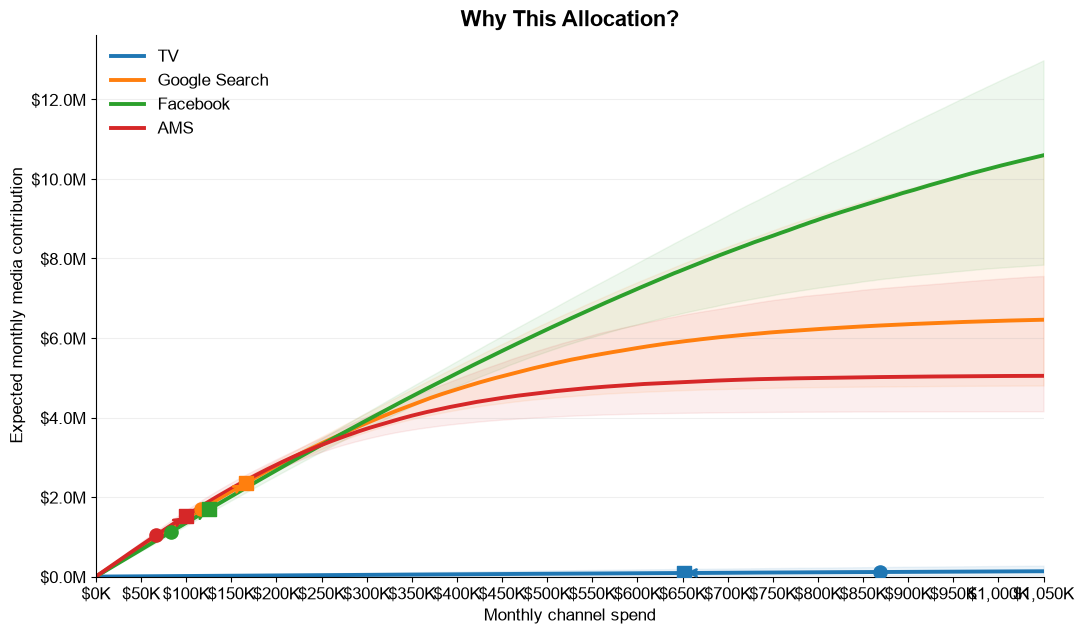

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator

KEY = ["TV", "Google Search", "Facebook", "AMS"]

SPEND_UNIT = 10_000       # 1 spend unit = $10K
REVENUE_UNIT = 250_000    # 1 revenue unit = $250K
WEEKS = 13
WEEKS_PER_MONTH = 52 / 12

target_scale = float(
    mmm.idata.constant_data["target_scale"].values
)

channel_scale = mmm.idata.constant_data["channel_scale"]

# ------------------------------------------------------------
# Common monthly-dollar range for EVERY channel
# ------------------------------------------------------------

current_monthly = {
    ch: float(current_allocation.sel(channel=ch))
        / WEEKS * SPEND_UNIT * WEEKS_PER_MONTH
    for ch in KEY
}

optimal_monthly = {
    ch: float(optimal_allocation.sel(channel=ch))
        / WEEKS * SPEND_UNIT * WEEKS_PER_MONTH
    for ch in KEY
}

STEP = 50_000

max_decision_spend = max(
    max(current_monthly.values()),
    max(optimal_monthly.values())
)

X_MAX = np.ceil(
    max_decision_spend * 1.20 / STEP
) * STEP


fig, ax = plt.subplots(figsize=(11, 6.5))

for ch in KEY:

    scale = float(
        channel_scale.sel(channel=ch).values
    )

    # Same monthly-dollar maximum for every channel
    weekly_model_max = (
        X_MAX / WEEKS_PER_MONTH / SPEND_UNIT
    )

    max_normalized = weekly_model_max / scale

    post = (
        mmm.idata.posterior[
            ["saturation_beta", "saturation_lam"]
        ]
        .sel(channel=[ch])
    )

    curve = mmm.saturation.sample_curve(
        post,
        max_value=max_normalized,
        num_points=250,
        random_seed=42,
    )

    # X: convert normalized model input -> monthly dollars
    x_norm = curve.coords["x"].values

    x_dollars = (
        x_norm
        * scale
        * SPEND_UNIT
        * WEEKS_PER_MONTH
    )

    # Y: convert weekly contribution -> monthly dollars
    curve_dollars = (
        curve
        * target_scale
        * REVENUE_UNIT
        * WEEKS_PER_MONTH
    )

    median = (
        curve_dollars
        .median(("chain", "draw"))
        .squeeze()
        .values
    )

    low = (
        curve_dollars
        .quantile(0.10, dim=("chain", "draw"))
        .squeeze()
        .values
    )

    high = (
        curve_dollars
        .quantile(0.90, dim=("chain", "draw"))
        .squeeze()
        .values
    )

    line, = ax.plot(
        x_dollars,
        median,
        lw=2.8,
        label=ch,
    )

    color = line.get_color()

    ax.fill_between(
        x_dollars,
        low,
        high,
        color=color,
        alpha=0.08,
    )

    # Current -> Optimized
    cx = current_monthly[ch]
    ox = optimal_monthly[ch]

    cy = np.interp(cx, x_dollars, median)
    oy = np.interp(ox, x_dollars, median)

    ax.scatter(cx, cy, s=90, color=color, marker="o", zorder=5)
    ax.scatter(ox, oy, s=100, color=color, marker="s", zorder=5)

    ax.annotate(
        "",
        xy=(ox, oy),
        xytext=(cx, cy),
        arrowprops=dict(
            arrowstyle="->",
            color=color,
            lw=2,
        ),
    )


ax.set_xlim(0, X_MAX)
ax.set_ylim(bottom=0)

ax.xaxis.set_major_locator(
    MultipleLocator(STEP)
)

ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda x, _: f"${x/1000:,.0f}K"
    )
)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda y, _: f"${y/1_000_000:.1f}M"
    )
)

ax.set_title(
    "Why This Allocation?",
    fontsize=16,
    weight="bold",
)

ax.set_xlabel(
    "Monthly channel spend"
)

ax.set_ylabel(
    "Expected monthly media contribution"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.2)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

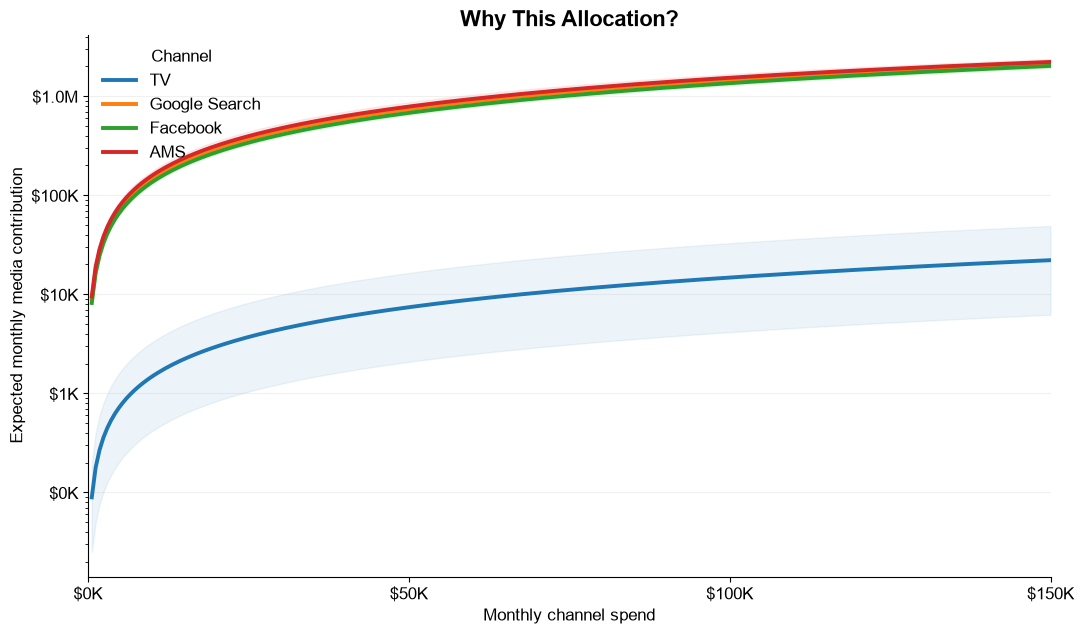

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator

KEY = ["TV", "Google Search", "Facebook", "AMS"]

SPEND_UNIT = 10_000        # 1 spend unit = $10K
REVENUE_UNIT = 250_000     # 1 revenue unit = $250K
WEEKS = 13
WEEKS_PER_MONTH = 52 / 12

target_scale = float(
    mmm.idata.constant_data["target_scale"].values
)

channel_scale = mmm.idata.constant_data["channel_scale"]

# ------------------------------------------------------------
# Focus only on the left side of the x-axis
# ------------------------------------------------------------

X_MAX = 150_000   # show only $0K to $150K per month

fig, ax = plt.subplots(figsize=(11, 6.5))

for ch in KEY:

    scale = float(
        channel_scale.sel(channel=ch).values
    )

    # Convert the common monthly-dollar range to model scale
    weekly_model_max = (
        X_MAX / WEEKS_PER_MONTH / SPEND_UNIT
    )

    max_normalized = weekly_model_max / scale

    post = (
        mmm.idata.posterior[
            ["saturation_beta", "saturation_lam"]
        ]
        .sel(channel=[ch])
    )

    curve = mmm.saturation.sample_curve(
        post,
        max_value=max_normalized,
        num_points=250,
        random_seed=42,
    )

    # X: normalized input -> monthly dollars
    x_norm = curve.coords["x"].values

    x_dollars = (
        x_norm
        * scale
        * SPEND_UNIT
        * WEEKS_PER_MONTH
    )

    # Y: weekly contribution -> monthly dollars
    curve_dollars = (
        curve
        * target_scale
        * REVENUE_UNIT
        * WEEKS_PER_MONTH
    )

    median = (
        curve_dollars
        .median(("chain", "draw"))
        .squeeze()
        .values
    )

    low = (
        curve_dollars
        .quantile(0.10, dim=("chain", "draw"))
        .squeeze()
        .values
    )

    high = (
        curve_dollars
        .quantile(0.90, dim=("chain", "draw"))
        .squeeze()
        .values
    )

    # log scale cannot display zero
    mask = median > 0

    x_plot = x_dollars[mask]
    median_plot = median[mask]
    low_plot = np.maximum(low[mask], 1)
    high_plot = high[mask]

    line, = ax.plot(
        x_plot,
        median_plot,
        lw=2.8,
        label=ch,
    )

    color = line.get_color()

    ax.fill_between(
        x_plot,
        low_plot,
        high_plot,
        color=color,
        alpha=0.08,
    )

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.set_xlim(0, X_MAX)
ax.set_yscale("log")

# fewer x-axis labels
ax.xaxis.set_major_locator(
    MultipleLocator(50_000)
)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x/1000:,.0f}K")
)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda y, _: (
            f"${y/1_000_000:.1f}M"
            if y >= 1_000_000
            else f"${y/1000:,.0f}K"
        )
    )
)

ax.set_title(
    "Why This Allocation?",
    fontsize=16,
    weight="bold",
)

ax.set_xlabel(
    "Monthly channel spend",
    fontsize=12,
)

ax.set_ylabel(
    "Expected monthly media contribution",
    fontsize=12,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.18,
    which="major",
)

ax.legend(
    title="Channel",
    frameon=False,
    loc="upper left",
)

plt.tight_layout()
plt.show()

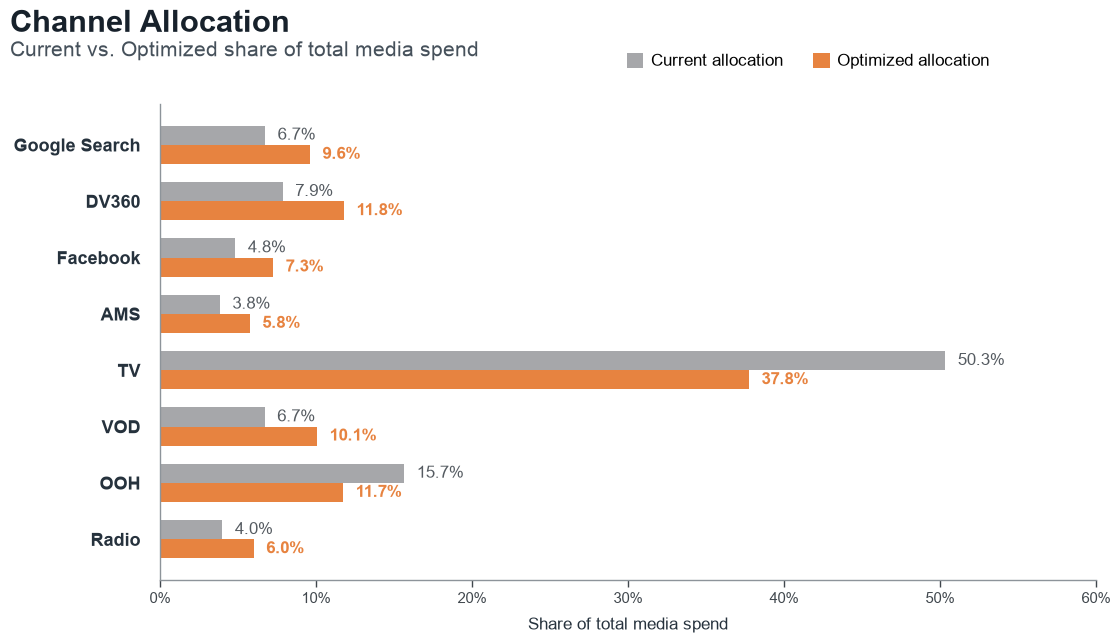

In [96]:
# ============================================================
# Channel Allocation — presentation style
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.patches import Patch

# ------------------------------------------------------------
# Data
# ------------------------------------------------------------

plot_df = comparison.loc[CHANNELS, ["Current Mix", "Optimal Mix"]].copy()

channels = plot_df.index
current_mix = plot_df["Current Mix"].values
optimal_mix = plot_df["Optimal Mix"].values

y = np.arange(len(channels))

# ------------------------------------------------------------
# Style
# ------------------------------------------------------------

CURRENT_COLOR = "#A6A7AA"    # gray from reference
OPTIMAL_COLOR = "#E78340"    # orange from reference
TEXT_COLOR = "#26323D"
AXIS_COLOR = "#8D949A"

bar_height = 0.34

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
})

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Current = upper bar
ax.barh(
    y - bar_height / 2,
    current_mix,
    height=bar_height,
    color=CURRENT_COLOR,
    edgecolor="none",
)

# Optimized = lower bar
ax.barh(
    y + bar_height / 2,
    optimal_mix,
    height=bar_height,
    color=OPTIMAL_COLOR,
    edgecolor="none",
)

# ------------------------------------------------------------
# Value labels
# ------------------------------------------------------------

for i, value in enumerate(current_mix):
    ax.text(
        value + 0.008,
        i - bar_height / 2,
        f"{value:.1%}",
        va="center",
        ha="left",
        fontsize=12,
        color="#555B61",
    )

for i, value in enumerate(optimal_mix):
    ax.text(
        value + 0.008,
        i + bar_height / 2,
        f"{value:.1%}",
        va="center",
        ha="left",
        fontsize=12,
        fontweight="bold",
        color=OPTIMAL_COLOR,
    )

# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------

ax.set_yticks(y)
ax.set_yticklabels(
    channels,
    fontsize=13,
    fontweight="bold",
    color=TEXT_COLOR,
)

ax.invert_yaxis()

ax.set_xlim(0, 0.60)
ax.set_xticks(np.arange(0, 0.61, 0.10))
ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

ax.tick_params(
    axis="x",
    labelsize=11,
    colors="#40474D",
    length=5,
    width=1,
)

ax.tick_params(
    axis="y",
    pad=14,
    length=0,
)

ax.set_xlabel(
    "Share of total media spend",
    fontsize=12,
    color=TEXT_COLOR,
    labelpad=8,
)

# No grid
ax.grid(False)

# Spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color(AXIS_COLOR)
ax.spines["left"].set_linewidth(1)

ax.spines["bottom"].set_color(AXIS_COLOR)
ax.spines["bottom"].set_linewidth(1)

# ------------------------------------------------------------
# Title + subtitle
# ------------------------------------------------------------

fig.text(
    0.055,
    0.955,
    "Channel Allocation",
    fontsize=22,
    fontweight="bold",
    color="#17212B",
    ha="left",
    va="top",
)

fig.text(
    0.055,
    0.910,
    "Current vs. Optimized share of total media spend",
    fontsize=15,
    color="#46515B",
    ha="left",
    va="top",
)

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

legend_handles = [
    Patch(facecolor=CURRENT_COLOR, label="Current allocation"),
    Patch(facecolor=OPTIMAL_COLOR, label="Optimized allocation"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.72, 0.915),
    ncol=2,
    frameon=False,
    fontsize=12,
    handlelength=1.0,
    handleheight=1.0,
    handletextpad=0.45,
    columnspacing=1.8,
)

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.subplots_adjust(
    left=0.18,
    right=0.96,
    bottom=0.14,
    top=0.82,
)

plt.show()